In [3]:
!md5 stage1_binary_pipeline_walkthrough.ipynb 2>/dev/null || md5sum stage1_binary_pipeline_walkthrough.ipynb

md5sum: stage1_binary_pipeline_walkthrough.ipynb: No such file or directory


# Stage 1 — Binary Classifier (Defect vs Normal): Pipeline Walkthrough

This notebook is not the primary way to run training; that remains the CLI:

```bash
python -m src.train_classification --config configs/classification/cls_stage1_binary.yaml
```

It replays the same logic step by step using the actual functions from
`src/` (not a reimplementation), so the pipeline can be read and understood
alongside intermediate outputs and visualizations.

**Prerequisites for the cells below to run:**
1. The stage 1 dataset has been built: `python scripts/build_stage1_binary.py ...`
2. `pip install -r requirements.txt`

If these are not in place, cells from "3. Dataset & DataLoader" onward will
fail to load data. That is expected; this notebook was written as a
reference before the data existed.

The `RUN_TRAINING_LOOP` flag in section 8 defaults to `False` so opening
this notebook does not accidentally trigger a full training run. Set it to
`True` to try a short demo run.


In [ ]:
import os
import sys
from pathlib import Path

if "__vsc_ipynb_file__" in globals():
    PROJECT_ROOT = Path(__vsc_ipynb_file__).resolve().parents[2]  # VS Code: cwd is the workspace, not the notebook dir
else:
    PROJECT_ROOT = Path.cwd().resolve().parents[1]  # Jupyter classic/Lab: cwd is the notebook's own dir

if not (PROJECT_ROOT / "requirements.txt").exists():
    raise RuntimeError(
        f"PROJECT_ROOT keliru: {PROJECT_ROOT} (gak ada requirements.txt di situ). "
        "Set manual sebelum lanjut, misal:\n"
        "    PROJECT_ROOT = Path('/Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection')"
    )

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import torch
import matplotlib.pyplot as plt

from src.data_loader import get_classification_dataloaders, IMAGENET_MEAN, IMAGENET_STD
from src.models.classification import build_model
from src.utils.seed import get_device, set_seed
from src.utils.class_weights import compute_class_weights
from src.utils.quantization import is_qat_supported, QAT_SUPPORTED_ARCHITECTURES
from src.train_classification import build_optimizer, train_one_epoch, evaluate

print(f"Project root: {PROJECT_ROOT}")
print(f"CUDA available: {torch.cuda.is_available()}")


## 1. Load config

All hyperparameters, dataset paths, and architecture choices live in one
yaml file rather than being hardcoded. Changing the config changes the
experiment without touching `src/`.


In [2]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "classification" / "cls_stage1_binary.yaml"
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

print(yaml.dump(config, sort_keys=False))


experiment_name: steel-defect/classification/stage1_binary
dataset:
  name: stage1_binary
  root: data/combined/stage1_binary
  num_classes: 2
  class_names:
  - Normal
  - Defect
img_size: 224
batch_size: 64
num_workers: 4
epochs: 30
seed: 42
optimizer:
  name: adamw
  lr: 0.0003
  weight_decay: 1.0e-05
scheduler:
  name: cosine
loss:
  weighted: false
  label_smoothing: 0.1
head:
  type: linear
quantization:
  enabled: true
  backend: qnnpack
  qat_start_epoch: 21
  freeze_observer_epoch: 26
  freeze_bn_stats_epoch: 28
early_stopping:
  patience: 8
  metric: recall_per_class.Defect
architectures:
- resnet18
- mobilenetv3_small
- efficientnetv2_s
output_dir: results/classification/stage1_binary



## 2. Reproducibility

`set_seed` fixes the random state for python/numpy/torch (CPU and GPU) and
disables cuDNN non-determinism, for reproducibility rather than performance.


In [3]:
set_seed(config.get("seed", 42))
device = get_device()  # CUDA > MPS (Apple Silicon) > CPU - lihat src/utils/seed.py
print(f"Device: {device}")


Device: mps


## 3. Dataset & DataLoader

`FolderClassificationDataset` (custom, not `torchvision.datasets.ImageFolder`)
reads images from `root/{train,val,test}/<class_name>/*.jpg`. Unlike the
built-in `ImageFolder`, label index order follows `class_names` from the
config rather than alphabetical order, to stay consistent with
`class_mapping.py` and class-weight computation.

Augmentation (`build_classification_transforms`) differs between train
(random crop/flip/rotate/color-jitter) and val/test (resize and center-crop
only, no randomness), so evaluation stays consistent across runs.


In [4]:
# take 100 example only

data = get_classification_dataloaders(config)
train_loader, val_loader, test_loader = data["train_loader"], data["val_loader"], data["test_loader"]

print(f"Train: {len(data['train_dataset'])} gambar")
print(f"Val:   {len(data['val_dataset'])} gambar")
print(f"Test:  {len(data['test_dataset'])} gambar")


Train: 7655 gambar
Val:   1641 gambar
Test:  1641 gambar


/Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


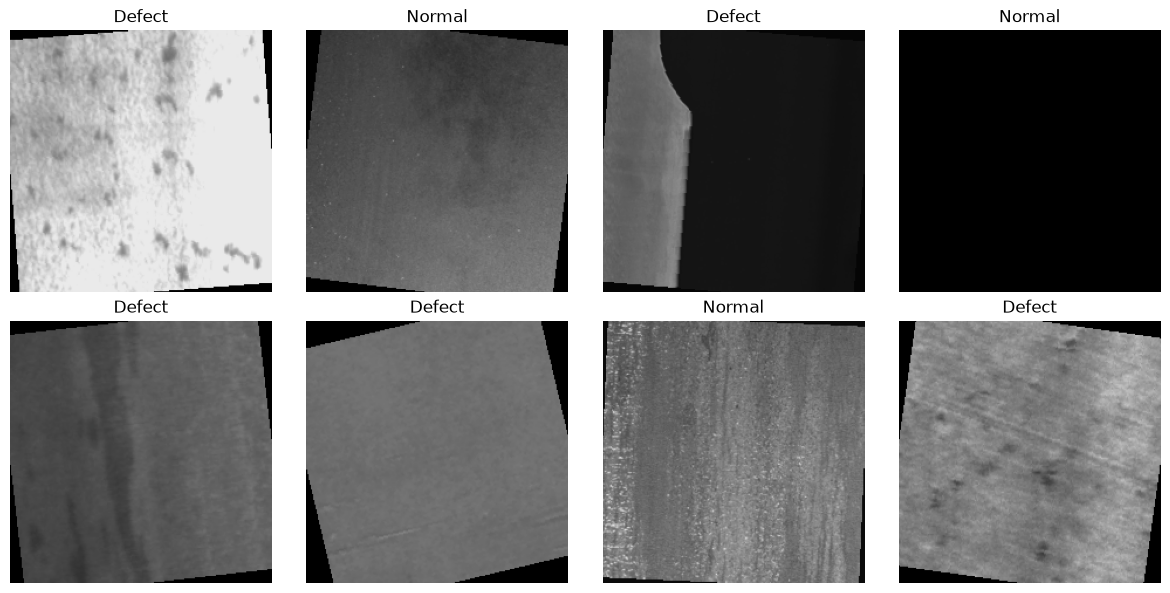

In [5]:
def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)


images, labels = next(iter(train_loader))
class_names = config["dataset"]["class_names"]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, label in zip(axes.flat, images[:8], labels[:8]):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(class_names[label.item()])
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Model: backbone + head

`build_model(arch_name, num_classes, head_cfg=...)` attaches an ImageNet
pretrained backbone (from `timm`) with a classifier head on top.

This config uses `head.type: mlp` (bottleneck Linear -> BatchNorm -> GELU ->
Dropout -> Linear). The reasoning differs from the NEU-CLS/X-SDD scenarios
(which need an MLP head because their datasets are small): stage 1's
dataset is large (~10.9k images), but combines four sources with very
different camera/domain characteristics (GC10, NEU-CLS, X-SDD, Severstal).
Since the Normal class is 100% Severstal and Defect is 100% from the other
three sources, a linear head has an easy shortcut available (source/camera
identity correlates perfectly with the label) instead of learning actual
defect texture. The bottleneck MLP with dropout forces the representation
through a non-linear compression step, which makes that shortcut harder to
rely on (a partial mitigation, not a guarantee).


In [8]:
arch_name = config["architectures"][0]  # contoh: resnet18
model = build_model(
    arch_name,
    config["dataset"]["num_classes"],
    pretrained=True,
    head_cfg=config.get("head"),
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Arsitektur: {arch_name}")
print(f"Total parameter: {n_params:,}")


Arsitektur: resnet18
Total parameter: 11,177,538


## 5. Loss function

`loss.weighted: false` in this config, since the dataset is already
stratified to ~1:1 balance (Defect:Normal) by `build_stage1_binary.py`,
unlike the 20-class combined scenario which requires `weighted: true`
(merged classes such as Inclusion/Scratches have far more samples).
`label_smoothing` is still used as a light regularizer.


In [10]:
loss_cfg = config.get("loss", {})
weight = None
if loss_cfg.get("weighted", False):
    weight = compute_class_weights(data["train_dataset"].labels, config["dataset"]["num_classes"]).to(device)
    print(f"Class weights: {weight}")
else:
    print("loss.weighted=false -> CrossEntropyLoss tanpa weight (dataset udah balanced)")

criterion = torch.nn.CrossEntropyLoss(weight=weight, label_smoothing=loss_cfg.get("label_smoothing", 0.0))


loss.weighted=false -> CrossEntropyLoss tanpa weight (dataset udah balanced)


## 6. Optimizer & scheduler

In [11]:
optimizer = build_optimizer(model, config.get("optimizer", {}))
print(optimizer)


AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 1e-05
)


## 7. Quantization-aware training (QAT) — optional

If `quantization.enabled: true` and the architecture is supported
(`QAT_SUPPORTED_ARCHITECTURES` — FX-traceable CNNs), training runs in fp32
until `qat_start_epoch`, then fake-quantization is enabled for the
remaining epochs (simulating int8 noise during training rather than only
at the end). This matters most for stage 1, which needs to stay
lightweight since it runs on every image before the decision to invoke the
detector.

The full mechanism (freezing the observer, freezing BN stats, converting to
true int8 at the end) lives in `src/utils/quantization.py`, orchestrated by
`src/train_classification.py::train_one_architecture`. This notebook only
shows the configuration; the full run happens via the CLI.


In [12]:
quant_cfg = config.get("quantization", {})
print(f"QAT enabled di config: {quant_cfg.get('enabled', False)}")
print(f"Arsitektur '{arch_name}' didukung QAT: {is_qat_supported(arch_name)}")
print(f"Arsitektur yang didukung QAT: {QAT_SUPPORTED_ARCHITECTURES}")
print(f"Backend: {quant_cfg.get('backend')}, mulai aktif epoch: {quant_cfg.get('qat_start_epoch')}")


QAT enabled di config: True
Arsitektur 'resnet18' didukung QAT: True
Arsitektur yang didukung QAT: ['resnet50', 'resnet18', 'efficientnetv2_s', 'mobilenetv3', 'mobilenetv3_small']
Backend: qnnpack, mulai aktif epoch: 21


## 8. Training loop

The actual loop (`train_one_architecture` in `src/train_classification.py`)
runs per epoch: `train_one_epoch` (forward, backward, step) ->
`evaluate` (compute validation metrics) -> save a checkpoint if the
monitored metric (`early_stopping.metric`, here `recall_per_class.Defect`)
improved -> check early stopping.

The cell below runs a short version (a few epochs, for demonstration) using
the same actual functions (`train_one_epoch`/`evaluate`), not a
reimplementation. For a full run (all architectures, all epochs, QAT, full
MLflow logging), use the CLI:

```bash
python -m src.train_classification --config configs/classification/cls_stage1_binary.yaml
```


In [14]:
from torch.utils.data import DataLoader, Subset

RUN_TRAINING_LOOP = True
DEMO_EPOCHS = 5
DEMO_SUBSET_SIZE = 200  # None = full dataset


def _random_subset_loader(dataset, n, seed=42):
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(len(dataset), generator=g)[: min(n, len(dataset))].tolist()
    return DataLoader(Subset(dataset, idx), batch_size=config["batch_size"], shuffle=True)


if RUN_TRAINING_LOOP:
    if DEMO_SUBSET_SIZE is not None:
        demo_train_loader = _random_subset_loader(data["train_dataset"], DEMO_SUBSET_SIZE)
        demo_val_loader = _random_subset_loader(data["val_dataset"], DEMO_SUBSET_SIZE // 4)
        demo_test_loader = _random_subset_loader(data["test_dataset"], DEMO_SUBSET_SIZE // 4)
    else:
        demo_train_loader, demo_val_loader, demo_test_loader = train_loader, val_loader, test_loader

    for epoch in range(1, DEMO_EPOCHS + 1):
        train_loss = train_one_epoch(model, demo_train_loader, optimizer, criterion, device)
        val_result = evaluate(model, demo_val_loader, device, class_names)
        recall_defect = val_result["scalars"]["recall_per_class.Defect"]
        print(f"epoch {epoch}: train_loss={train_loss:.4f} val_recall_Defect={recall_defect:.4f}")
else:
    print("RUN_TRAINING_LOOP=False, skip eksekusi. Set True buat coba training beneran (butuh dataset + waktu).")


epoch 1: train_loss=0.5911 val_recall_Defect=1.0000


epoch 2: train_loss=0.5188 val_recall_Defect=1.0000


epoch 3: train_loss=0.4596 val_recall_Defect=1.0000


epoch 4: train_loss=0.3943 val_recall_Defect=1.0000


epoch 5: train_loss=0.3551 val_recall_Defect=1.0000


## 9. Evaluation & confusion matrix

`evaluate()` returns a dict with all metrics (accuracy, precision/recall/F1
macro, weighted, and per-class, AUC), a confusion matrix, and a
classification report — the same data logged to MLflow during actual
training runs.


              precision    recall  f1-score   support

      Normal       1.00      0.87      0.93        30
      Defect       0.83      1.00      0.91        20

    accuracy                           0.92        50
   macro avg       0.92      0.93      0.92        50
weighted avg       0.93      0.92      0.92        50



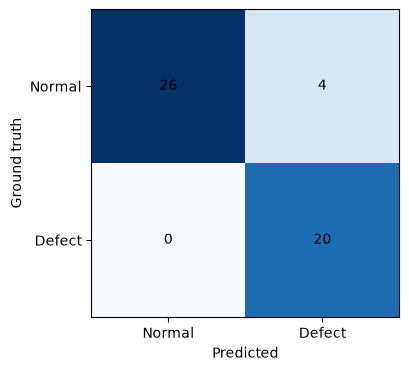

In [15]:
if RUN_TRAINING_LOOP:
    test_result = evaluate(model, demo_test_loader, device, class_names)
    print(test_result["classification_report"])

    cm = test_result["confusion_matrix"]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names)
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Ground truth")
    plt.show()
else:
    print("Skip - RUN_TRAINING_LOOP masih False, belum ada model yang beneran ke-training.")


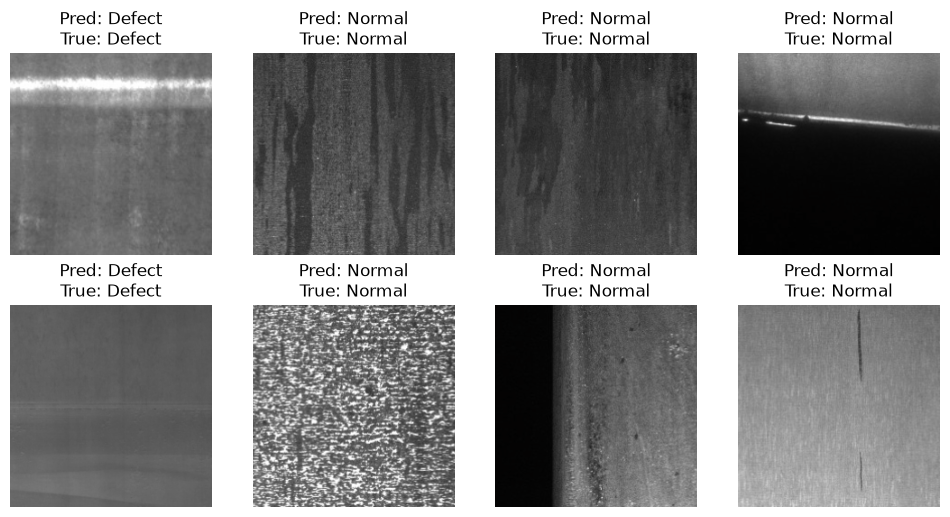

In [18]:
#Print sample test inference

test_images, test_labels = next(iter(demo_test_loader))
plt.figure(figsize=(12, 6))
for i in range(min(8, len(test_images))):
    img = test_images[i].unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img)
        pred_label = output.argmax(dim=1).item()
    plt.subplot(2, 4, i + 1)
    plt.imshow(denormalize(test_images[i]).permute(1, 2, 0).cpu().numpy())
    plt.title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[test_labels[i].item()]}")
    plt.axis("off")
plt.show()
